In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("retail_price.csv")
data.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [5]:
data.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

In [6]:
# Remove unnecessary columns
data = data.drop(columns=["total_price", "product_id", "month_year"])

In [7]:
# Check missing values
data.isnull().sum()

product_category_name         0
qty                           0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int64

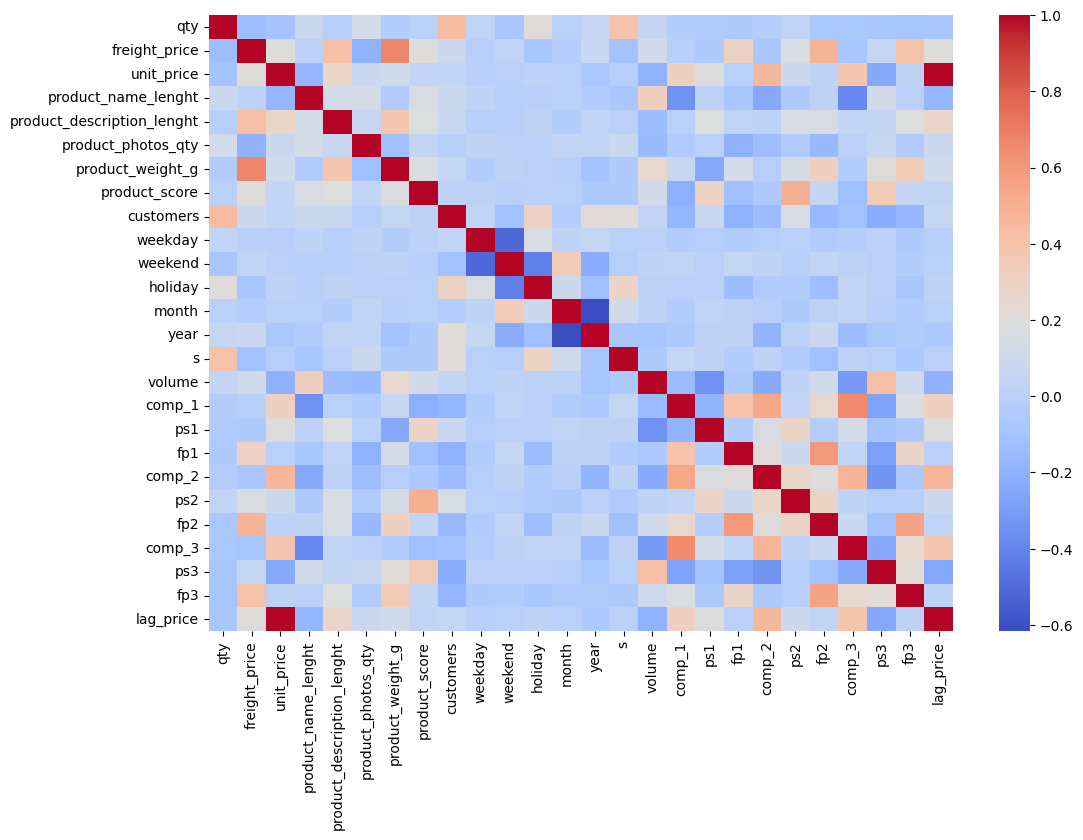

In [11]:
#correlation
numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm")
plt.show()

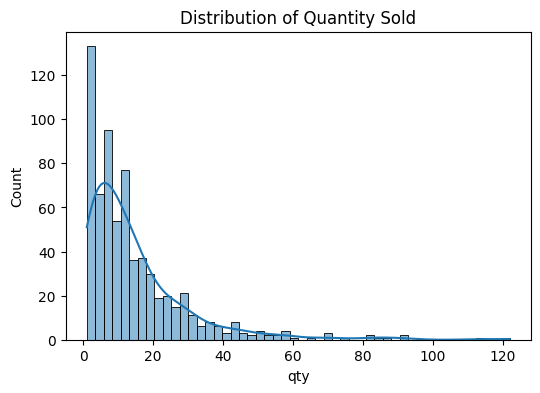

Mean qty: 14.495562130177515
Median qty: 10.0


In [15]:
#Demand Distribution
plt.figure(figsize=(6,4))
sns.histplot(data["qty"], bins=50, kde=True)
plt.title("Distribution of Quantity Sold")
plt.show()

print("Mean qty:", data["qty"].mean())
print("Median qty:", data["qty"].median())


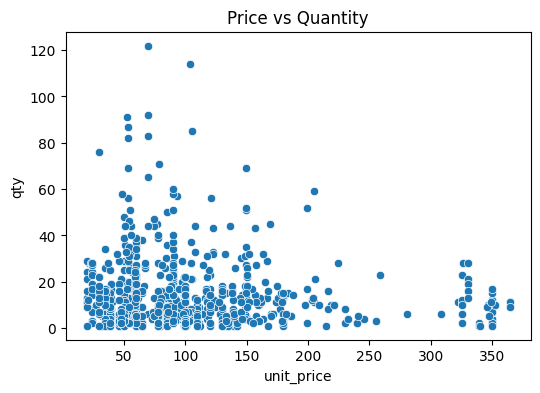

In [18]:
#price vs demand
plt.figure(figsize=(6,4))
sns.scatterplot(x="unit_price", y="qty", data=data)
plt.title("Price vs Quantity")
plt.show()

In [20]:
#Competitor Price Effect
print("Comp_1 correlation:", data["comp_1"].corr(data["qty"]))
print("Comp_2 correlation:", data["comp_2"].corr(data["qty"]))
print("Comp_3 correlation:", data["comp_3"].corr(data["qty"]))

Comp_1 correlation: -0.033570215101854234
Comp_2 correlation: -0.027044219200455827
Comp_3 correlation: -0.06852193134883762


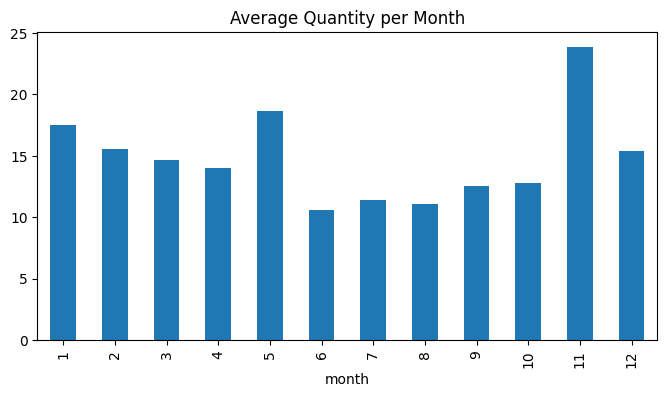

In [21]:
#Seasonal Effect
monthly_sales = data.groupby("month")["qty"].mean()

plt.figure(figsize=(8,4))
monthly_sales.plot(kind="bar")
plt.title("Average Quantity per Month")
plt.show()

In [23]:
#Holiday Effect
data.groupby("holiday")["qty"].mean()

holiday
0    11.285714
1    12.784974
2    14.884146
3    22.450000
4    23.886364
Name: qty, dtype: float64